# Cartesian Meshes

In [ ]:
import numpy as np
from pprint import pprint
from lucifex.mesh import rectangle_mesh
from lucifex.fem import Function
from lucifex.viz import plot_colormap, create_animation, plot_line, plot_bar, save_figure
from lucifex.fe2py import as_grid_function, cross_section
from lucifex.utils.py_utils import log_timing, nested_dict

Nx = 256
Ny = 256
mesh = rectangle_mesh(2.0, 1.0, Ny, Ny)

u = Function((mesh, 'P', 1), lambda x: x[0] * x[1], name='u')
w = Function((mesh, 'P', 1), lambda x: x[0] * x[1] ** 2, name='w')

In [ ]:
f_opts = (u, w)
use_map_opts = (True, False)
jit_opts = (True, False)
results_texec = nested_dict((Function, bool, bool, list[float]), depth=3)
results_grid = nested_dict((Function, bool, bool, np.ndarray), depth=3)

for f in f_opts:
    for use_map in use_map_opts:
        for jit in jit_opts:
            f_grid = log_timing(as_grid_function, results_texec[f.name][use_map], jit, n=3)(
                u, jit=jit, use_mesh_map=use_map, use_mesh_cache=False
            )
            results_grid[f.name][use_map][jit] = f_grid

# pprint(results_texec, sort_dicts=False)

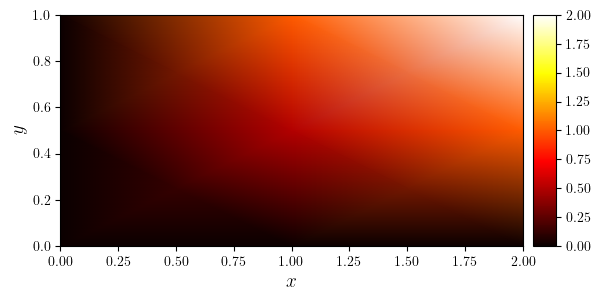

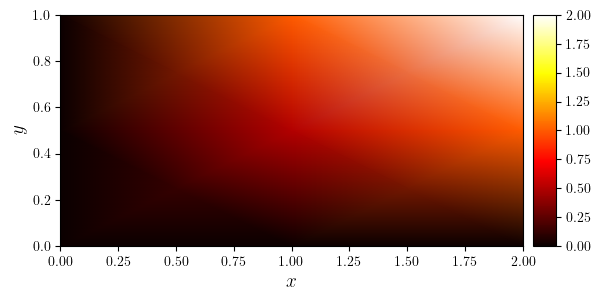

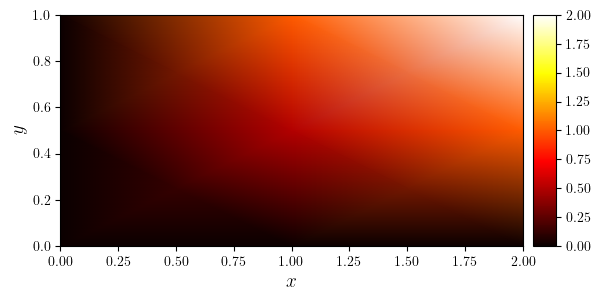

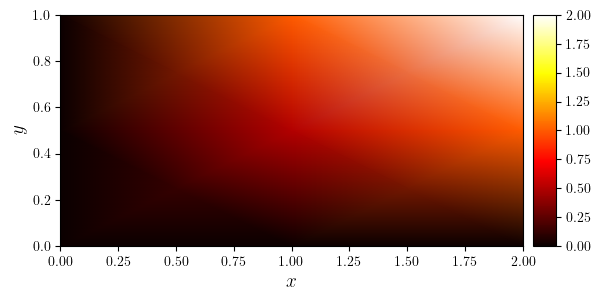

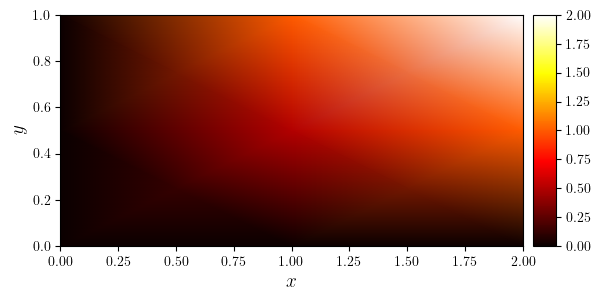

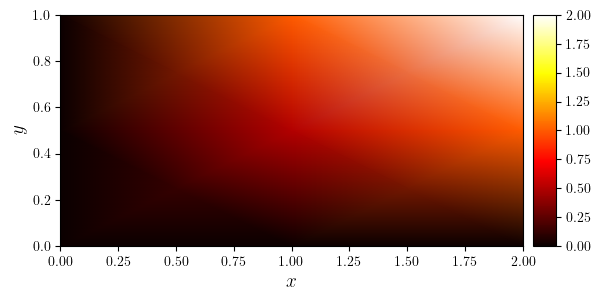

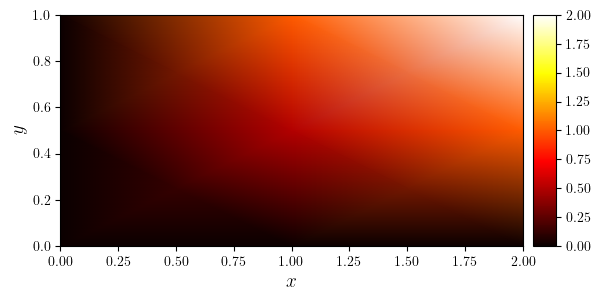

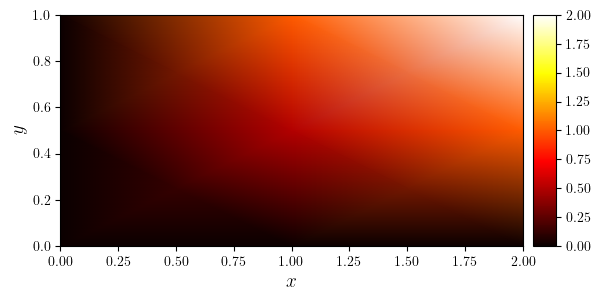

: 

In [ ]:
x, y = grid(mesh)

for f in f_opts:
    for use_map in use_map_opts:
        for jit in jit_opts:
            f_grid = results_grid[f.name][use_map][jit]
            plot_colormap((x, y, f_grid))